Dataset loaded successfully!

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Stre

C:\Users\ADS2609024\AppData\Local\Temp\9\ipykernel_12812\4238840145.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


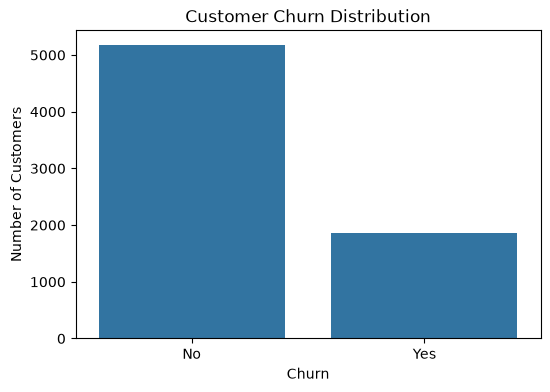


Churn rate by Contract:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


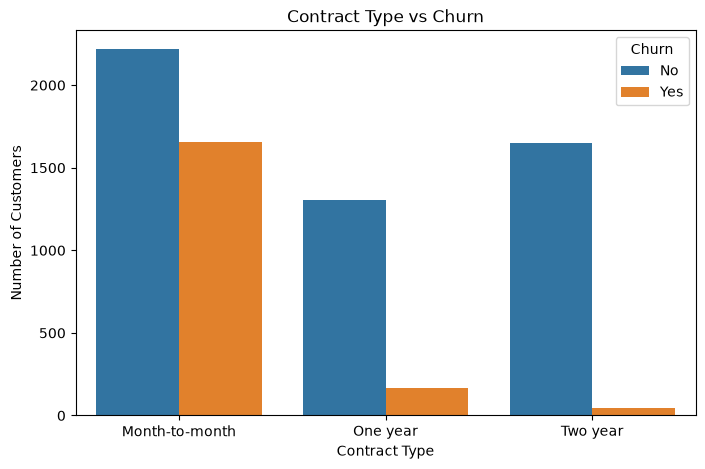


Churn rate by Internet Service:
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


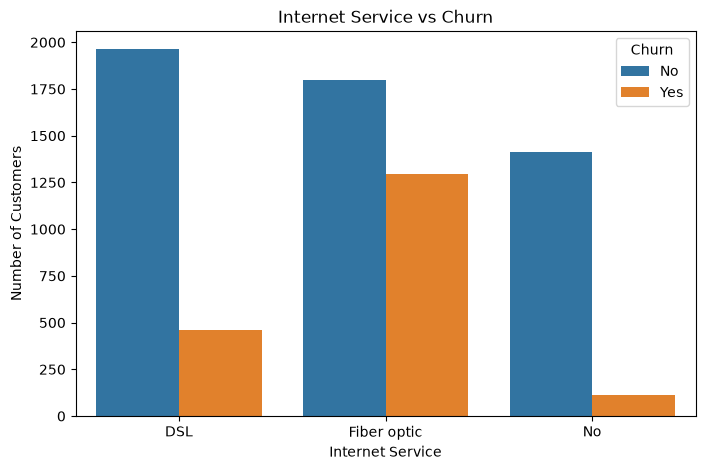


Churn rate by Payment Method:
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


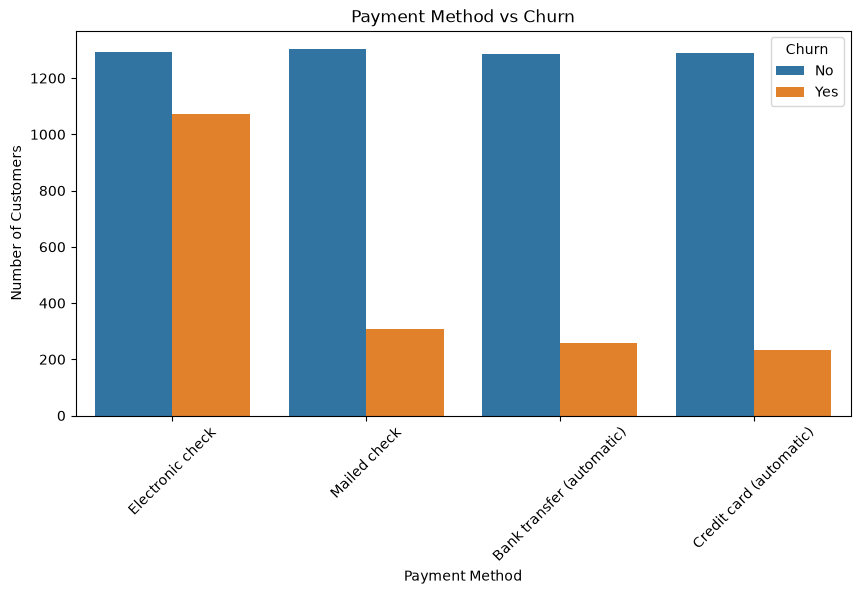

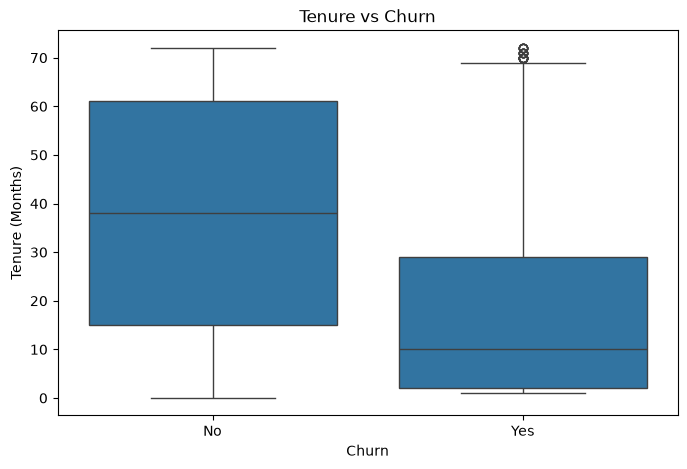

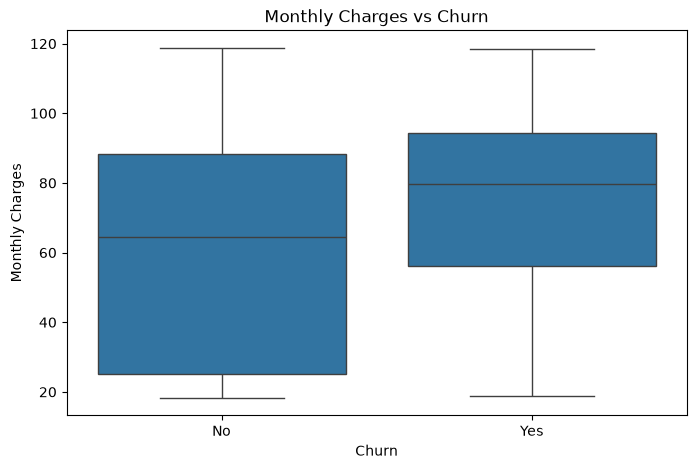

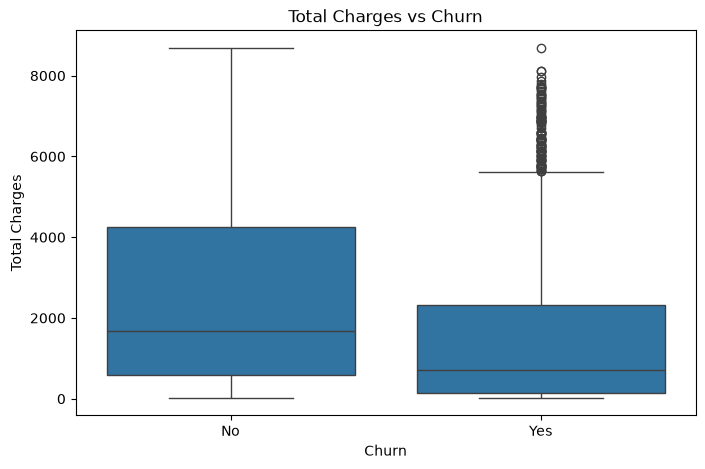


Final missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Final dataset shape:
(7043, 21)

Final dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure     

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(
    r"E:\lebika_training\WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("Dataset loaded successfully!")


print("\nFirst 5 rows:")
print(df.head())


print("\nDataset shape:")
print(df.shape)


print("\nColumn names:")
print(df.columns)


print("\nDataset information:")
print(df.info())


print("\nData types:")
print(df.dtypes)


numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = df.select_dtypes(
    include=["object"]
).columns

print("\nNumerical features:")
print(list(numerical_features))

print("\nCategorical features:")
print(list(categorical_features))


print("\nStatistical summary:")
print(df.describe())


print("\nMissing values:")
print(df.isnull().sum())


df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("\nMissing values after converting TotalCharges:")
print(df.isnull().sum())


df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print("\nMissing values after handling:")
print(df.isnull().sum())



print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)



print("\nChurn distribution:")
print(df["Churn"].value_counts())



churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("\nChurn percentage:")
print(churn_percentage)



plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()



contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn rate by Contract:")
print(contract_churn)




plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()



internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn rate by Internet Service:")
print(internet_churn)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()


payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn rate by Payment Method:")
print(payment_churn)



plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()



plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()



print("\nFinal missing values:")
print(df.isnull().sum())



print("\nFinal dataset shape:")
print(df.shape)



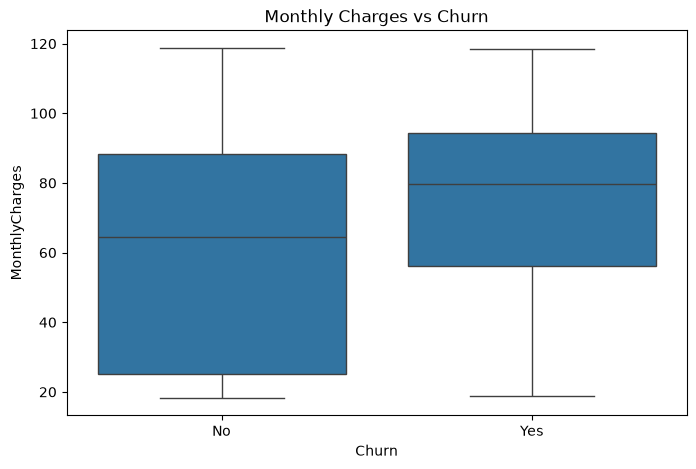

In [2]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

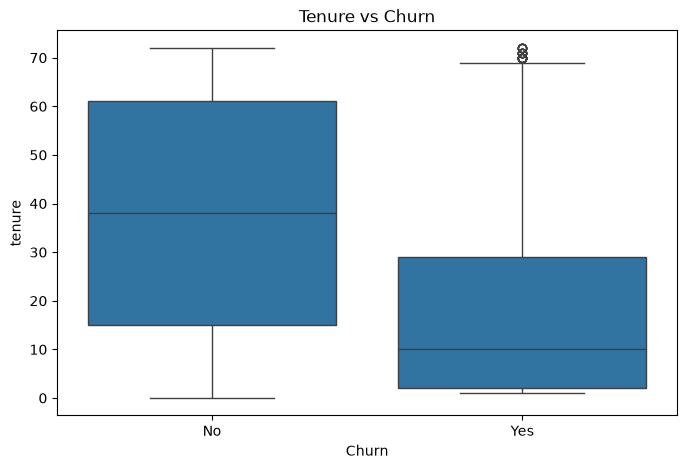

In [3]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")

plt.show()

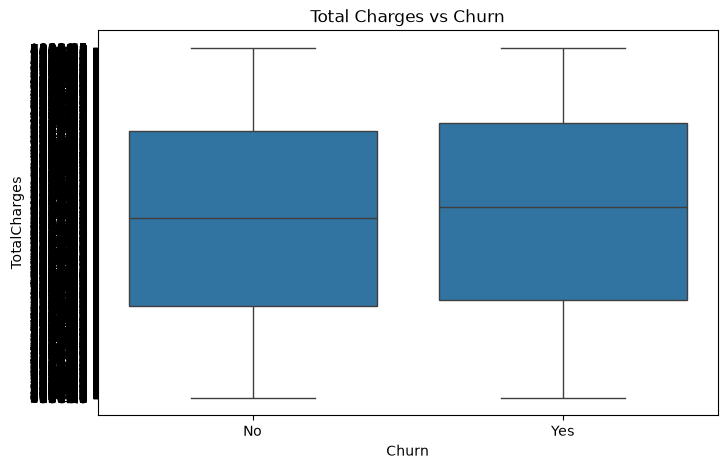

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="TotalCharges", data=df)

plt.title("Total Charges vs Churn")

plt.show()

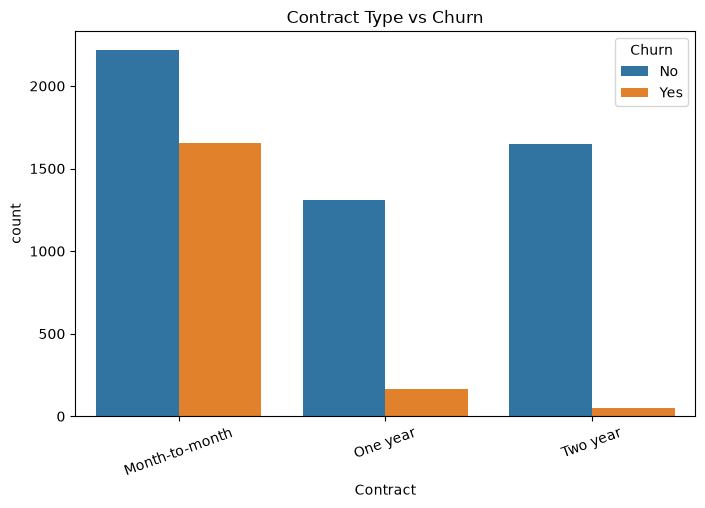

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)

plt.show()

In [27]:
df = df.drop(columns=["customerID"], errors="ignore")




# --------------------------------------------
# 5. Create new feature
# --------------------------------------------
# Total charges per month

df["ChargesPerMonth"] = (
    df["TotalCharges"] /
    df["tenure"].replace(0, 1)
)

print("\nNew ChargesPerMonth feature:")
print(
    df[[
        "tenure",
        "TotalCharges",
        "ChargesPerMonth"
    ]].head()
)


# --------------------------------------------
# 6. One-Hot Encoding
# --------------------------------------------
# Convert categorical Yes/No/text columns
# into numerical columns.

df = pd.get_dummies(
    df,
    drop_first=True
)



# --------------------------------------------
# 7. Separate X and y
# --------------------------------------------
# X = input features
# y = target (Churn)

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

print("\nX shape:")
print(X.shape)

print("\ny shape:")
print(y.shape)

print("\nTarget values:")
print(y.head())


# --------------------------------------------
# 8. Standardize numerical features
# --------------------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)




# --------------------------------------------
# 9. Split data
# --------------------------------------------
# 60% Training
# 20% Validation
# 20% Testing

from sklearn.model_selection import train_test_split

# First: 60% train + 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42
)

# Second: divide remaining 40% equally
# 20% validation + 20% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)


# --------------------------------------------
# 10. Display final split
# --------------------------------------------

print("\nFinal Data Split:")

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Testing data:", X_test.shape)

print("\nTarget split:")

print("Training target:", y_train.shape)
print("Validation target:", y_val.shape)
print("Testing target:", y_test.shape)


New ChargesPerMonth feature:
   tenure  TotalCharges  ChargesPerMonth
0       1         29.85        29.850000
1      34       1889.50        55.573529
2       2        108.15        54.075000
3      45       1840.75        40.905556
4       2        151.65        75.825000

X shape:
(7043, 32)

y shape:
(7043,)

Target values:
0    False
1    False
2     True
3    False
4     True
Name: Churn_Yes, dtype: bool

Final Data Split:
Training data: (4225, 32)
Validation data: (1409, 32)
Testing data: (1409, 32)

Target split:
Training target: (4225,)
Validation target: (1409,)
Testing target: (1409,)


In [18]:
print(df.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ChargesPerMonth', 'gender_Male', 'Partner_Yes', 'Dependents_Yes',
       'PhoneService_Yes', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='str')


X_train shape: (4225, 32)
X_val shape: (1409, 32)
X_test shape: (1409, 32)
Learning Rate: 0.001
Initial Cost: 0.6931471803599454
Final Cost: 0.5668026209751578

Learning Rate: 0.01
Initial Cost: 0.6931471803599454
Final Cost: 0.44164105470380893

Learning Rate: 0.1
Initial Cost: 0.6931471803599454
Final Cost: 0.42620534772228413

Learning Rate: 1.0
Initial Cost: 0.6931471803599454
Final Cost: 0.4245843463162481



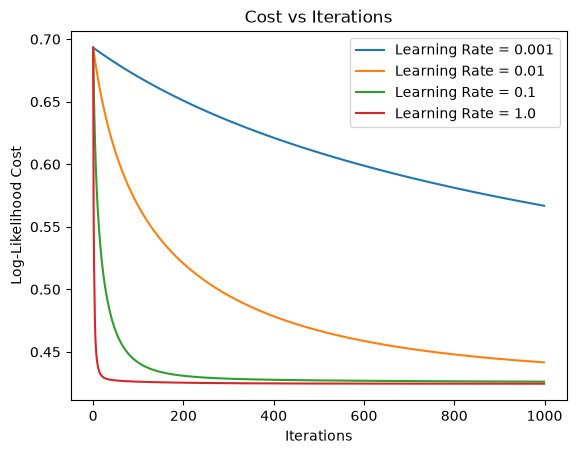

In [19]:
# ============================================
# LOGISTIC REGRESSION FROM SCRATCH
# ============================================

import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------
# 1. Add intercept column
# --------------------------------------------

X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_val_bias   = np.c_[np.ones(X_val.shape[0]), X_val]
X_test_bias  = np.c_[np.ones(X_test.shape[0]), X_test]

print("X_train shape:", X_train_bias.shape)
print("X_val shape:", X_val_bias.shape)
print("X_test shape:", X_test_bias.shape)


# --------------------------------------------
# 2. Sigmoid function
# --------------------------------------------

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# --------------------------------------------
# 3. Logistic Regression Training
# --------------------------------------------

def train_logistic_regression(X, y, learning_rate, iterations):

    weights = np.zeros(X.shape[1])

    costs = []

    for i in range(iterations):

        # Calculate z
        z = np.dot(X, weights)

        # Sigmoid
        probability = sigmoid(z)

        # Log-likelihood cost
        cost = -np.mean(
            y * np.log(probability + 1e-10) +
            (1 - y) * np.log(1 - probability + 1e-10)
        )

        costs.append(cost)

        # Error
        error = probability - y

        # Gradient
        dw = np.dot(X.T, error) / len(y)

        # Update weights
        weights = weights - learning_rate * dw

    return weights, costs


# --------------------------------------------
# 4. Test different learning rates
# --------------------------------------------

learning_rates = [0.001, 0.01, 0.1, 1.0]

results = {}

for lr in learning_rates:

    weights, costs = train_logistic_regression(
        X_train_bias,
        y_train,
        learning_rate=lr,
        iterations=1000
    )

    results[lr] = {
        "weights": weights,
        "costs": costs
    }

    print("Learning Rate:", lr)
    print("Initial Cost:", costs[0])
    print("Final Cost:", costs[-1])
    print()


# --------------------------------------------
# 5. Plot cost / convergence
# --------------------------------------------

for lr in learning_rates:

    plt.plot(
        results[lr]["costs"],
        label="Learning Rate = " + str(lr)
    )

plt.xlabel("Iterations")
plt.ylabel("Log-Likelihood Cost")
plt.title("Cost vs Iterations")
plt.legend()
plt.show()

First 10 Actual Values:
[False  True False False  True  True  True False False False]

First 10 Predicted Values:
[0 0 0 0 1 1 1 0 0 1]

Confusion Matrix:
True Positive : 217
True Negative : 935
False Positive: 103
False Negative: 154

Accuracy: 0.8176011355571328
Precision: 0.678125
Recall: 0.5849056603773585
F1 Score: 0.6280752532561504

========== FINAL METRICS ==========
Accuracy : 0.8176
Precision: 0.6781
Recall   : 0.5849
F1 Score : 0.6281


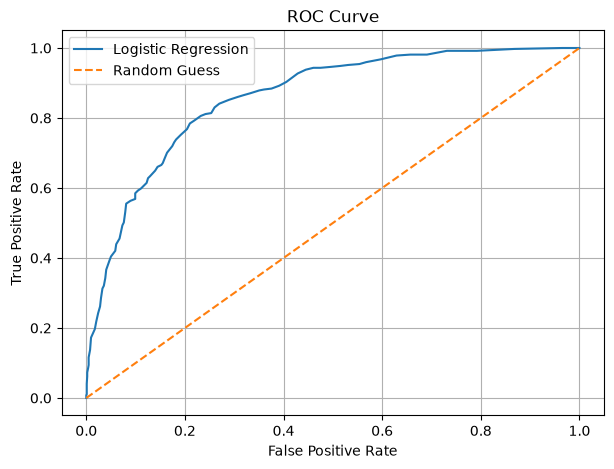

AUC: -0.8594


In [20]:
# ============================================
# MODEL EVALUATION & INTERPRETATION
# ============================================

import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------
# 1. Select trained model
# --------------------------------------------

best_lr = 0.1

weights = results[best_lr]["weights"]


# --------------------------------------------
# 2. Predict probabilities
# --------------------------------------------

z = np.dot(X_test_bias, weights)

y_probability = 1 / (1 + np.exp(-np.clip(z, -500, 500)))


# --------------------------------------------
# 3. Convert probability to 0 or 1
# --------------------------------------------

y_pred = (y_probability >= 0.5).astype(int)

print("First 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred[:10])


# ============================================
# 4. Confusion Matrix MANUALLY
# ============================================

TP = np.sum((y_test.values == 1) & (y_pred == 1))
TN = np.sum((y_test.values == 0) & (y_pred == 0))
FP = np.sum((y_test.values == 0) & (y_pred == 1))
FN = np.sum((y_test.values == 1) & (y_pred == 0))

print("\nConfusion Matrix:")
print("True Positive :", TP)
print("True Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)


# ============================================
# 5. Accuracy MANUALLY
# ============================================

accuracy = (TP + TN) / (TP + TN + FP + FN)

print("\nAccuracy:", accuracy)


# ============================================
# 6. Precision MANUALLY
# ============================================

precision = TP / (TP + FP)

print("Precision:", precision)


# ============================================
# 7. Recall MANUALLY
# ============================================

recall = TP / (TP + FN)

print("Recall:", recall)


# ============================================
# 8. F1 Score MANUALLY
# ============================================

f1 = 2 * (precision * recall) / (precision + recall)

print("F1 Score:", f1)


# ============================================
# 9. Display all metrics
# ============================================

print("\n========== FINAL METRICS ==========")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


# ============================================
# 10. ROC Curve MANUALLY
# ============================================

thresholds = np.arange(0, 1.01, 0.01)

TPR = []
FPR = []

for threshold in thresholds:

    prediction = (y_probability >= threshold).astype(int)

    tp = np.sum((y_test.values == 1) & (prediction == 1))
    tn = np.sum((y_test.values == 0) & (prediction == 0))
    fp = np.sum((y_test.values == 0) & (prediction == 1))
    fn = np.sum((y_test.values == 1) & (prediction == 0))

    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)

    TPR.append(tpr)
    FPR.append(fpr)


# ============================================
# 11. Plot ROC Curve
# ============================================

plt.figure(figsize=(7, 5))

plt.plot(FPR, TPR, label="Logistic Regression")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid()
plt.show()


# ============================================
# 12. Calculate AUC MANUALLY
# ============================================

auc = np.trapezoid(TPR, FPR)

print("AUC:", round(auc, 4))

Feature Importance:
                           Feature  Coefficient  Importance
1                           tenure    -0.683746    0.683746
26               Contract_Two year    -0.614493    0.614493
11     InternetService_Fiber optic     0.387747    0.387747
25               Contract_One year    -0.284466    0.284466
14              OnlineSecurity_Yes    -0.181542    0.181542
27            PaperlessBilling_Yes     0.150022    0.150022
24             StreamingMovies_Yes     0.146021    0.146021
2                   MonthlyCharges     0.144349    0.144349
29  PaymentMethod_Electronic check     0.137564    0.137564
20                 TechSupport_Yes    -0.132725    0.132725

Top 10 Most Important Features:
                           Feature  Coefficient  Importance
1                           tenure    -0.683746    0.683746
26               Contract_Two year    -0.614493    0.614493
11     InternetService_Fiber optic     0.387747    0.387747
25               Contract_One year    -0.284466

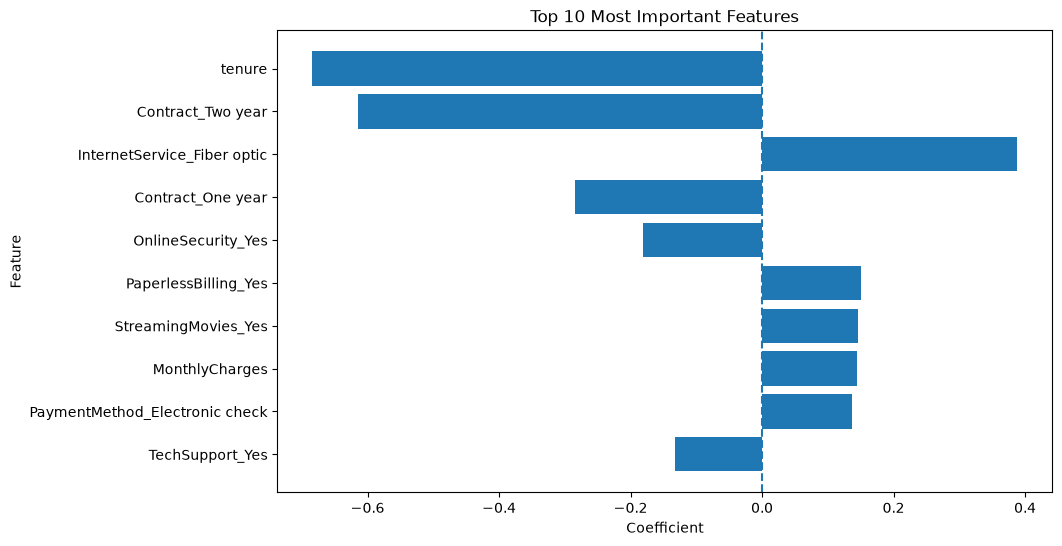

In [25]:
feature_names = df.drop(columns=["Churn_Yes"]).columns

# --------------------------------------------
# 2. Get model coefficients
# --------------------------------------------
# First weight is the intercept, so remove it

coefficients = weights[1:]


# --------------------------------------------
# 3. Create feature importance table
# --------------------------------------------

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Importance": np.abs(coefficients)
})


# --------------------------------------------
# 4. Sort by importance
# --------------------------------------------

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(importance_df.head(10))


# --------------------------------------------
# 5. Display top 10 features
# --------------------------------------------

top10 = importance_df.head(10)

print("\nTop 10 Most Important Features:")
print(top10)


# --------------------------------------------
# 6. Plot top 10 features
# --------------------------------------------

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"],
    top10["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.axvline(0, linestyle="--")

plt.show()

In [26]:
# Customer Lifetime Value
df["CLV"] = df["MonthlyCharges"] * df["tenure"]

print("Customer Lifetime Value:")
print(df[["MonthlyCharges", "tenure", "CLV"]].head())

# Average CLV of customers who churned
churned_clv = df[df["Churn_Yes"] == 1]["CLV"].mean()

# Average CLV of customers who stayed
retained_clv = df[df["Churn_Yes"] == 0]["CLV"].mean()

print("\nAverage CLV of Churned Customers:", round(churned_clv, 2))
print("Average CLV of Retained Customers:", round(retained_clv, 2))

# Total CLV lost because of churn
total_clv_lost = df[df["Churn_Yes"] == 1]["CLV"].sum()

print("\nTotal CLV Impact of Churn:", round(total_clv_lost, 2))

Customer Lifetime Value:
   MonthlyCharges  tenure      CLV
0           29.85       1    29.85
1           56.95      34  1936.30
2           53.85       2   107.70
3           42.30      45  1903.50
4           70.70       2   141.40

Average CLV of Churned Customers: 1531.61
Average CLV of Retained Customers: 2549.77

Total CLV Impact of Churn: 2862576.9
